# Detecting full-text pages from text-extent features

A *full-text page* is one where transcribed text occupies the page from near the top to near
the bottom — the text column runs the full height of the page.

We detect full-text pages using four *margin* features and two *line-uniformity* features,
all computed from the PageXML line coordinates:

| Feature | Meaning |
|---------|--------------------------------------------|
| `top`   | `min(line.top) / page.height`             — how far down text starts |
| `bot`   | `(page.height − max(line.bottom)) / page.height` — how far from the bottom text ends |
| `left`  | `min(line.left) / page.width`             — leftmost text extent |
| `right` | `(page.width − max(line.right)) / page.width` — rightmost text extent |
| `mean_width` | mean `(line.right − line.left) / page.width` — average relative line width |
| `equal_frac` | fraction of consecutive row-group pairs whose horizontal extents are Allen-`equal` within 2% tolerance |

The first four features identify the text envelope of each page.  Pages whose top and bottom
margins are within a tolerance of the inventory's *stable* (10th-percentile) values are
classified **`full_text`**; larger deviations give **`late_start`**, **`early_end`**, or
**`short`**.

The last two features reveal whether the page contains *table cells* or *running text*:
table-register pages have many short, narrow cell-entry lines at scattered left positions
(low `mean_width`, low `equal_frac`), while running-text pages have wide lines that consistently
span the full column (high `mean_width`, high `equal_frac`).

**Six inventories across two corpus types:**

- **`NL-HaNA_2.10.50_1`**, **`NL-HaNA_2.10.50_85`**, **`NL-HaNA_2.10.50_619`** — table registers
  from the National Archives (NL-HaNA, archive 2.10.50).  Each page is a column-structured
  table; individual table cells are separate PageXML text regions.
- **`NL-AsnDA_0114.11_1`** — notary deeds, Amsterdam Notarial Archive.  Running text, one deed
  per page (or part of a page), with a blank verso or recto on the other half.
- **`NL-HaNA_1.01.02_11182`**, **`NL-HaNA_1.01.02_11281`** — letter-copy books, National
  Archives (NL-HaNA, archive 1.01.02).  Copies of letters written consecutively with no large
  empty regions between them; nearly every page is full running text.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    split_inventory_into_pages, get_opening_features, is_opening,
)
from archival_structures.analysis.text_extent import (
    compute_corpus_text_extents,
    estimate_stable_margins,
    classify_corpus_text_extents,
    full_text_page_fraction,
)

DATA = Path('../../data')

# (kind, xml_dir, thumb_dir)
INVENTORIES = {
    'NL-HaNA_2.10.50_1':    ('table_register',
                              DATA / 'PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1',
                              DATA / 'thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
    'NL-HaNA_2.10.50_85':   ('table_register',
                              DATA / 'PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_85',
                              None),
    'NL-HaNA_2.10.50_619':  ('table_register',
                              DATA / 'PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_619',
                              None),
    'NL-AsnDA_0114.11_1':   ('running_text',
                              DATA / 'PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1',
                              DATA / 'thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
    'NL-HaNA_1.01.02_11182': ('running_text',
                               DATA / 'PageXML/NL-HaNA/NL-HaNA_1.01.02/11182',
                               DATA / 'thumbs/NL-HaNA/NL-HaNA_1.01.02/11182'),
    'NL-HaNA_1.01.02_11281': ('running_text',
                               DATA / 'PageXML/NL-HaNA/NL-HaNA_1.01.02/11281',
                               DATA / 'thumbs/NL-HaNA/NL-HaNA_1.01.02/11281'),
}

COLOURS = {
    'full_text':  '#2196F3',
    'late_start': '#FF9800',
    'early_end':  '#E91E63',
    'short':      '#9C27B0',
}

## Load pages and compute text-extent features

We load all available scans for each inventory, split two-page openings into individual pages,
and compute all six text-extent features for every non-empty page.

In [2]:
corpus = {}

for inv_id, (kind, xml_dir, thumb_dir) in INVENTORIES.items():
    xml_files = sorted(xml_dir.glob('*.xml'))
    scans  = [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_files]
    pages  = split_inventory_into_pages(scans)
    df     = compute_corpus_text_extents(pages)
    stable = estimate_stable_margins(df)
    classes = classify_corpus_text_extents(df, stable)
    corpus[inv_id] = {
        'kind': kind, 'pages': pages, 'df': df,
        'stable': stable, 'classes': classes, 'thumb_dir': thumb_dir,
    }
    n_full = int((classes == 'full_text').sum())
    print(f"{inv_id} ({kind})\n"
          f"  {len(pages)} pages, {len(df)} non-empty | "
          f"full_text {n_full}/{len(df)} ({n_full/len(df):.0%}) | "
          f"mean_width {df['mean_width'].mean():.3f} | "
          f"equal_frac {df['equal_frac'].mean():.3f}")

NL-HaNA_2.10.50_1 (table_register)
  578 pages, 560 non-empty | full_text 374/560 (67%) | mean_width 0.164 | equal_frac 0.143


NL-HaNA_2.10.50_85 (table_register)
  349 pages, 342 non-empty | full_text 237/342 (69%) | mean_width 0.150 | equal_frac 0.139


NL-HaNA_2.10.50_619 (table_register)
  577 pages, 570 non-empty | full_text 121/570 (21%) | mean_width 0.092 | equal_frac 0.107


NL-AsnDA_0114.11_1 (running_text)
  630 pages, 604 non-empty | full_text 541/604 (90%) | mean_width 0.236 | equal_frac 0.306


NL-HaNA_1.01.02_11182 (running_text)
  755 pages, 749 non-empty | full_text 723/749 (97%) | mean_width 0.280 | equal_frac 0.392


NL-HaNA_1.01.02_11281 (running_text)
  1139 pages, 1119 non-empty | full_text 1096/1119 (98%) | mean_width 0.275 | equal_frac 0.401


## Top and bottom margin distributions

The shape of the margin distribution reveals the document type:

- A **narrow peak** at a small margin value means pages consistently start (or end) text at the
  same vertical position — typical of a book with uniform running text.
- A **wide or flat distribution** means the text start/end position varies between pages —
  typical of a table register (variable row counts) or a heterogeneous mixed document.

The vertical dashed line shows the *stable margin* (10th percentile); the dotted line the
stable + 5% tolerance threshold.

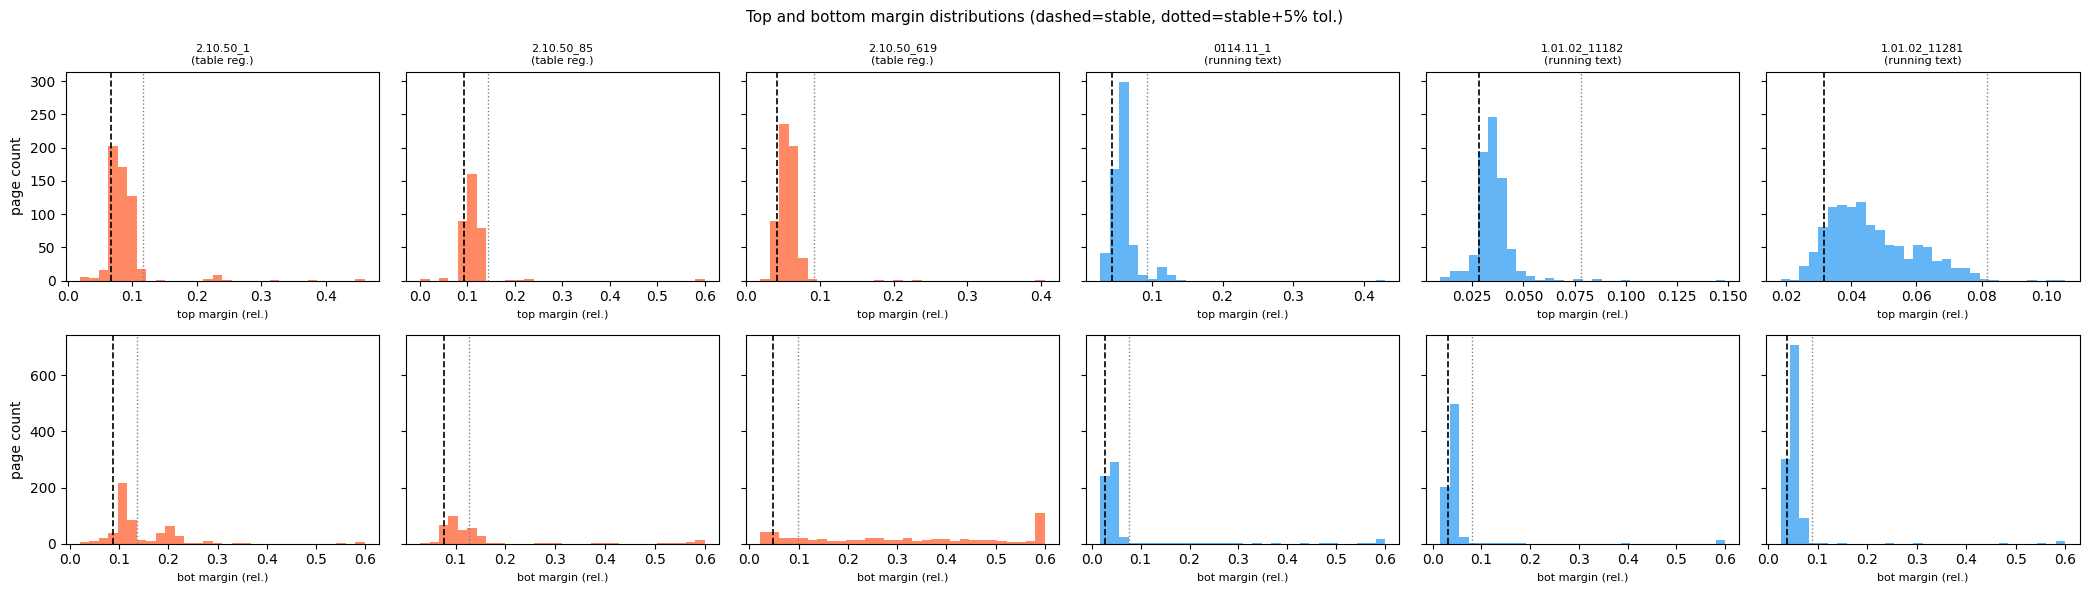

In [3]:
inv_ids = list(corpus)
fig, axes = plt.subplots(2, len(inv_ids), figsize=(3.5 * len(inv_ids), 6), sharey='row')

for col, inv_id in enumerate(inv_ids):
    info = corpus[inv_id]
    df, stable, kind = info['df'], info['stable'], info['kind']
    colour = '#2196F3' if kind == 'running_text' else '#FF5722'
    label  = 'running text' if kind == 'running_text' else 'table reg.'

    for row, col_name in enumerate(('top', 'bot')):
        ax = axes[row, col]
        ax.hist(df[col_name].clip(0, 0.6), bins=30, color=colour, alpha=0.7)
        ax.axvline(stable[col_name], color='black', linestyle='--', linewidth=1.2)
        ax.axvline(stable[col_name] + 0.05, color='gray', linestyle=':', linewidth=1)
        short_id = inv_id.split('_', 1)[-1]
        if row == 0:
            ax.set_title(f"{short_id}\n({label})", fontsize=8)
        ax.set_xlabel('top margin (rel.)' if row == 0 else 'bot margin (rel.)', fontsize=8)
        if col == 0:
            ax.set_ylabel('page count')

plt.suptitle('Top and bottom margin distributions'
             ' (dashed=stable, dotted=stable+5% tol.)', fontsize=11)
plt.tight_layout()
plt.show()

## Full-text page classification

Each page is classified as `full_text`, `late_start`, `early_end`, or `short` based on
whether its top/bottom margins exceed the stable margin plus the 5% tolerance.

In [4]:
rows = []
for inv_id, info in corpus.items():
    vc = info['classes'].value_counts()
    total = len(info['df'])
    rows.append({
        'inventory':    inv_id,
        'type':         info['kind'],
        'non-empty':    total,
        'full_text %':  f"{100 * vc.get('full_text', 0) / total:.0f}%",
        'early_end %':  f"{100 * vc.get('early_end', 0) / total:.0f}%",
        'late_start %': f"{100 * vc.get('late_start', 0) / total:.0f}%",
        'short %':      f"{100 * vc.get('short', 0) / total:.0f}%",
        'mean_width':   f"{info['df']['mean_width'].mean():.3f}",
        'equal_frac':   f"{info['df']['equal_frac'].mean():.3f}",
    })

summary = pd.DataFrame(rows).set_index('inventory')
display(summary)

,type,non-empty,full_text %,early_end %,late_start %,short %,mean_width,equal_frac
inventory,,,,,,,,
NL-HaNA_2.10.50_1,table_register,560,67%,30%,1%,3%,0.164,0.143
NL-HaNA_2.10.50_85,table_register,342,69%,29%,1%,1%,0.150,0.139
NL-HaNA_2.10.50_619,table_register,570,21%,78%,0%,1%,0.092,0.107
NL-AsnDA_0114.11_1,running_text,604,90%,5%,2%,3%,0.236,0.306
NL-HaNA_1.01.02_11182,running_text,749,97%,3%,0%,0%,0.280,0.392
NL-HaNA_1.01.02_11281,running_text,1119,98%,2%,0%,0%,0.275,0.401


## Class composition per inventory

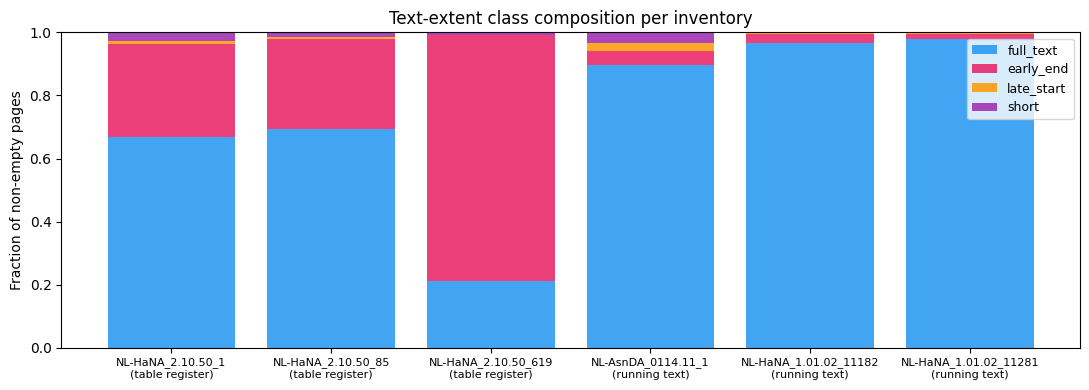

In [5]:
CLASS_ORDER = ['full_text', 'early_end', 'late_start', 'short']

fractions = {}
for inv_id, info in corpus.items():
    vc = info['classes'].value_counts(normalize=True)
    fractions[inv_id] = {cls: vc.get(cls, 0.0) for cls in CLASS_ORDER}

fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(corpus))
x = np.arange(len(corpus))

for cls in CLASS_ORDER:
    vals = np.array([fractions[inv_id][cls] for inv_id in corpus])
    ax.bar(x, vals, bottom=bottom, label=cls, color=COLOURS[cls], alpha=0.85)
    bottom += vals

ax.set_xticks(x)
inv_labels = [f"{k}\n({v['kind'].replace('_', ' ')})" for k, v in corpus.items()]
ax.set_xticklabels(inv_labels, fontsize=8)
ax.set_ylabel('Fraction of non-empty pages')
ax.set_title('Text-extent class composition per inventory')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Distinguishing table pages from running-text pages

Two of the three table registers (`NL-HaNA_2.10.50_1` and `_85`) have a 67-69% full-text
fraction — nearly as high as the notary deeds.  The top/bottom margin alone therefore can not
separate them from running-text inventories.  The two line-uniformity features do:

* **`mean_width`** — In a table register, each PageXML text line wraps the actual text content
  of a single table cell, which is typically only a few characters wide (a date, a number, a
  short name).  These cell entries are narrow: the mean relative line width is ≈ 0.09–0.16 for
  table registers.  In a running-text book, each line spans most of the column: ≈ 0.24–0.28.

* **`equal_frac`** — Two consecutive lines are Allen-`equal` (within 2% tolerance) when they
  share nearly the same left *and* right boundary.  Running-text lines that fill the full
  column tend to do this consistently (≈ 0.30–0.40).  Table-cell lines may share a left
  boundary (same column) but their right extents vary with cell content, giving a much lower
  fraction (≈ 0.10–0.14).

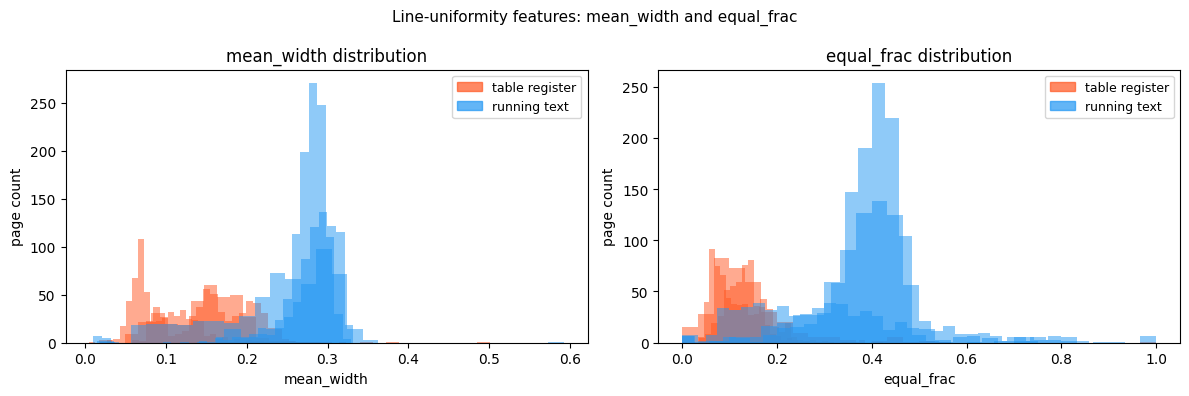

inventory                      type               mean_width   equal_frac
------------------------------------------------------------------------
NL-HaNA_2.10.50_1              table_register          0.164        0.143
NL-HaNA_2.10.50_85             table_register          0.150        0.139
NL-HaNA_2.10.50_619            table_register          0.092        0.107
NL-AsnDA_0114.11_1             running_text            0.236        0.306
NL-HaNA_1.01.02_11182          running_text            0.280        0.392
NL-HaNA_1.01.02_11281          running_text            0.275        0.401


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col_idx, feat in enumerate(('mean_width', 'equal_frac')):
    ax = axes[col_idx]
    for inv_id, info in corpus.items():
        colour = '#2196F3' if info['kind'] == 'running_text' else '#FF5722'
        lbl = inv_id.split('_', 1)[-1]
        vals = info['df'][feat].clip(0, 1)
        ax.hist(vals, bins=30, alpha=0.5, color=colour, label=lbl)
    ax.set_xlabel(feat)
    ax.set_ylabel('page count')
    ax.set_title(f'{feat} distribution')

# Legend: show just type colours
from matplotlib.patches import Patch
handles = [Patch(color='#FF5722', alpha=0.7, label='table register'),
           Patch(color='#2196F3', alpha=0.7, label='running text')]
axes[0].legend(handles=handles, fontsize=9)
axes[1].legend(handles=handles, fontsize=9)

plt.suptitle('Line-uniformity features: mean_width and equal_frac', fontsize=11)
plt.tight_layout()
plt.show()

# Print per-inventory means
print(f"{'inventory':<30} {'type':<16} {'mean_width':>12} {'equal_frac':>12}")
print('-' * 72)
for inv_id, info in corpus.items():
    print(f"{inv_id:<30} {info['kind']:<16} "
          f"{info['df']['mean_width'].mean():>12.3f} "
          f"{info['df']['equal_frac'].mean():>12.3f}")

## Page examples with margin annotations

For inventories with available thumbnails we show representative pages per text-extent class.
A **blue overlay** marks the top-margin region (from page top to first text line); a
**red overlay** marks the bottom-margin region (from last text line to page bottom).

In [7]:
def find_thumbnail(thumb_dir, scan_id):
    stem = scan_id.replace('.jp2', '').replace('.jpg', '')
    return next(Path(thumb_dir).glob(f'*{stem}*'))


_info_pages = []  # filled in show_class_examples

def page_crop(page, thumb_dir):
    """Thumbnail image cropped to this page's half (or the full scan if not split)."""
    scan_id = page.id
    is_split = scan_id.endswith('-verso') or scan_id.endswith('-recto')
    base = scan_id[:-len('-verso')] if scan_id.endswith('-verso') else scan_id[:-len('-recto')]
    try:
        thumb_path = find_thumbnail(thumb_dir, base if is_split else scan_id)
    except StopIteration:
        thumb_path = find_thumbnail(thumb_dir, scan_id.split('-verso')[0].split('-recto')[0])
    img = Image.open(thumb_path).convert('RGB')
    if not is_split:
        return img
    w, h = img.size
    mid = w // 2
    for p in _info_pages:
        if p.id == base and is_opening(p):
            feat = get_opening_features(p)
            mid = int(feat.separation_point.x * w / p.coords.width)
            break
    return img.crop((0, 0, mid, h)) if scan_id.endswith('-verso') else img.crop((mid, 0, w, h))


def annotate_margins(img, top_frac, bot_frac, alpha=100):
    """Draw semi-transparent top (blue) and bottom (red) margin overlays."""
    w, h = img.size
    overlay = Image.new('RGBA', (w, h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    top_px = int(top_frac * h)
    bot_px = int((1 - bot_frac) * h)
    draw.rectangle([0, 0, w, top_px], fill=(33, 150, 243, alpha))
    draw.rectangle([0, bot_px, w, h],  fill=(233, 30, 99, alpha))
    return Image.alpha_composite(img.convert('RGBA'), overlay).convert('RGB')


def show_class_examples(inv_id, n_per_class=3):
    global _info_pages
    info = corpus[inv_id]
    thumb_dir = info['thumb_dir']
    if thumb_dir is None:
        print(f"{inv_id}: no thumbnails available")
        return
    df, classes = info['df'], info['classes']
    pages_by_id = {p.id: p for p in info['pages']}
    _info_pages = info['pages']

    class_names = [c for c in ['full_text', 'early_end', 'late_start', 'short']
                   if c in classes.values]
    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(3 * n_per_class, 5 * len(class_names)))
    if len(class_names) == 1:
        axes = axes[np.newaxis, :]

    for row, cls in enumerate(class_names):
        examples = classes[classes == cls].index[:n_per_class]
        for col, page_id in enumerate(examples):
            ax = axes[row, col]
            page = pages_by_id.get(page_id)
            if page is None:
                ax.axis('off'); continue
            row_data = df.loc[page_id]
            try:
                img = page_crop(page, thumb_dir)
                img = annotate_margins(img, row_data['top'], row_data['bot'])
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, str(e), transform=ax.transAxes,
                        ha='center', va='center', fontsize=7)
            label = (f"{page_id}\ntop={row_data['top']:.3f}  bot={row_data['bot']:.3f}\n"
                     f"width={row_data['mean_width']:.3f}  eq={row_data['equal_frac']:.2f}")
            ax.set_title(label, fontsize=6)
            ax.axis('off')
        axes[row, 0].set_ylabel(cls, fontsize=9, rotation=0, ha='right', labelpad=50)

    plt.suptitle(f'{inv_id} — text-extent classes\n'
                 f'(blue = top margin  red = bottom margin)', fontsize=10)
    plt.tight_layout()
    plt.show()

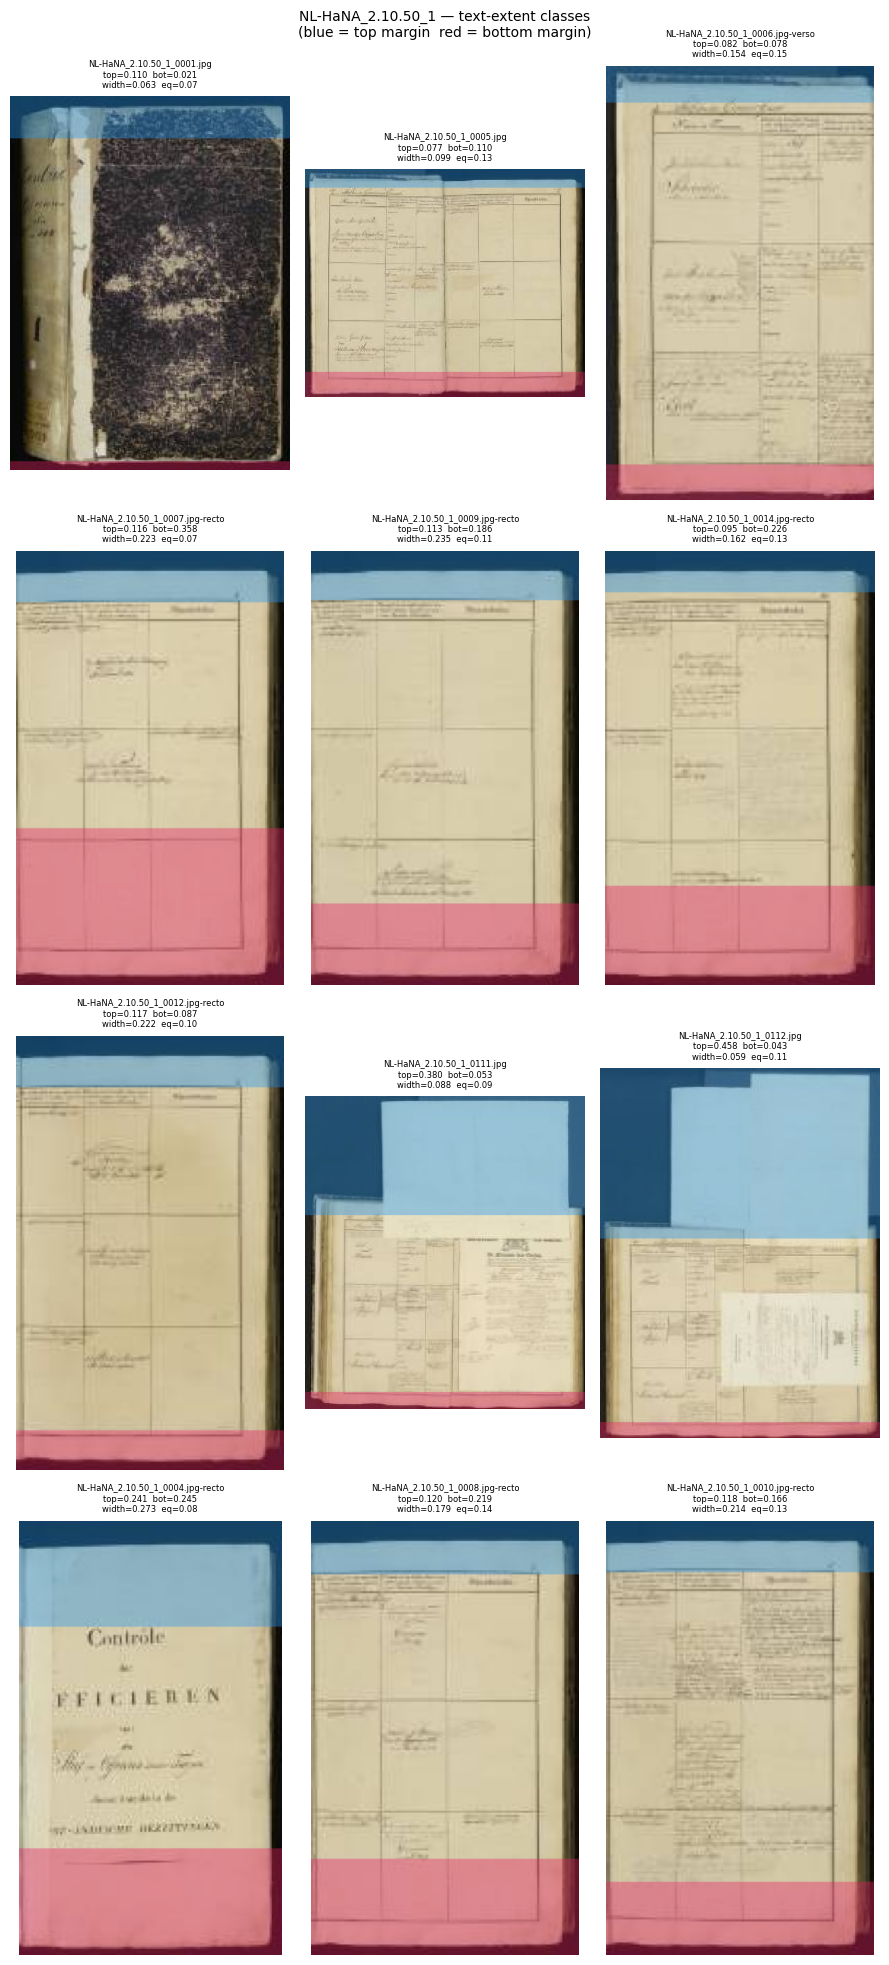

In [8]:
show_class_examples('NL-HaNA_2.10.50_1', n_per_class=3)

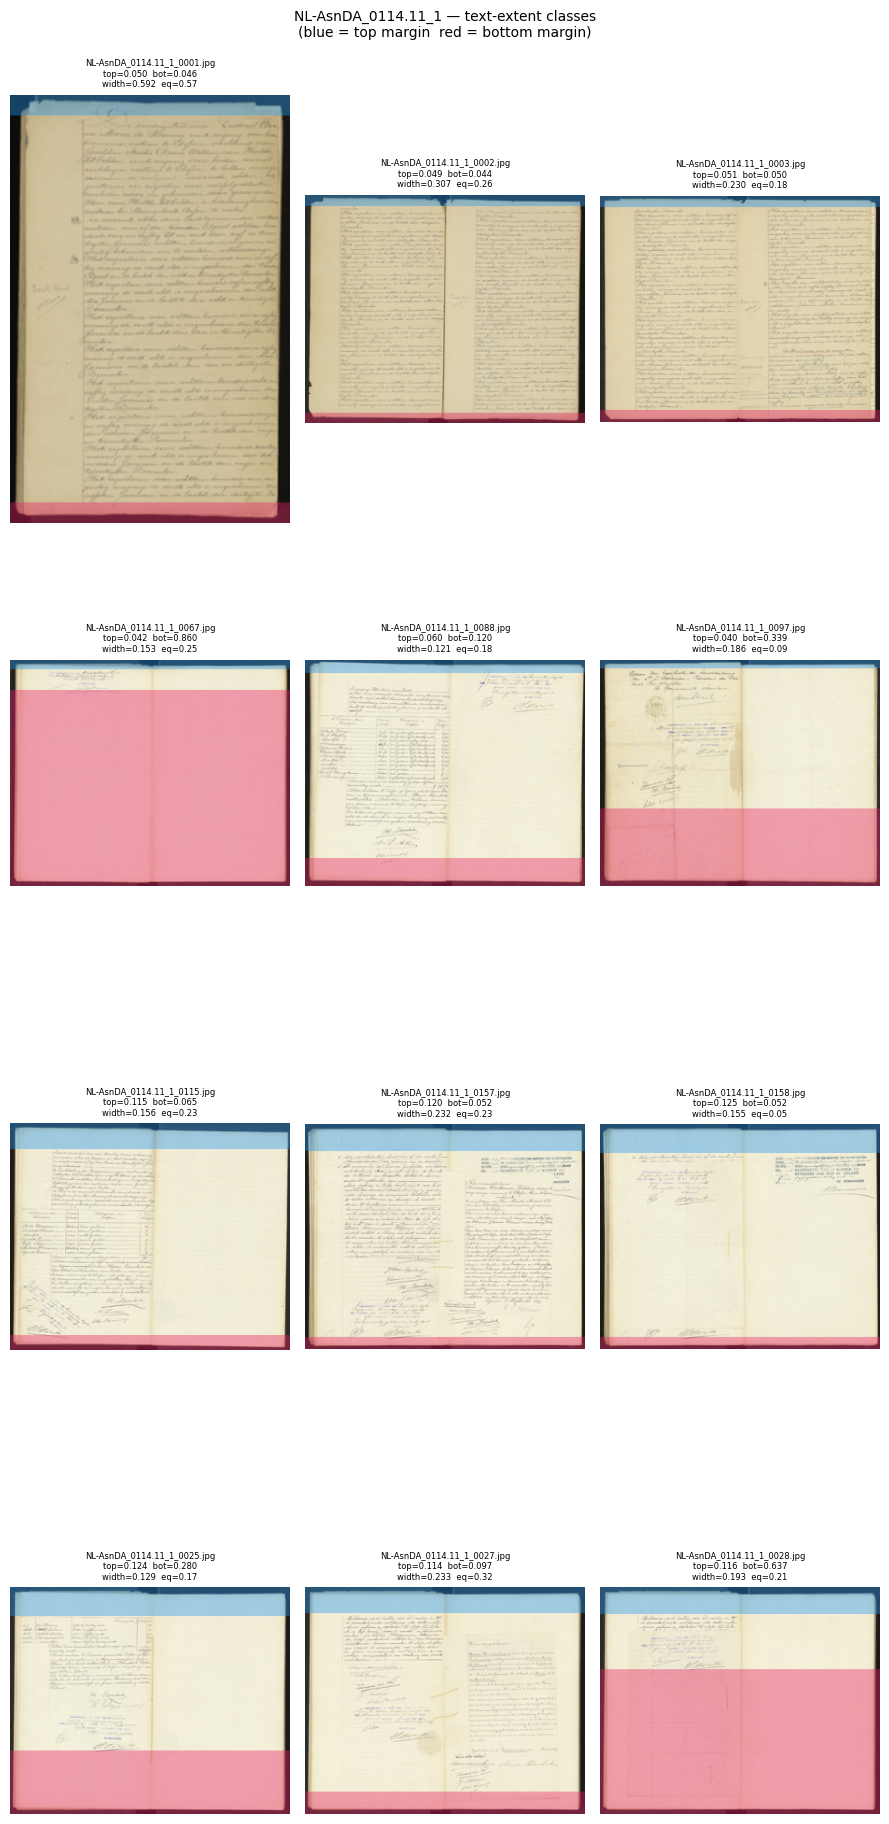

In [9]:
show_class_examples('NL-AsnDA_0114.11_1', n_per_class=3)

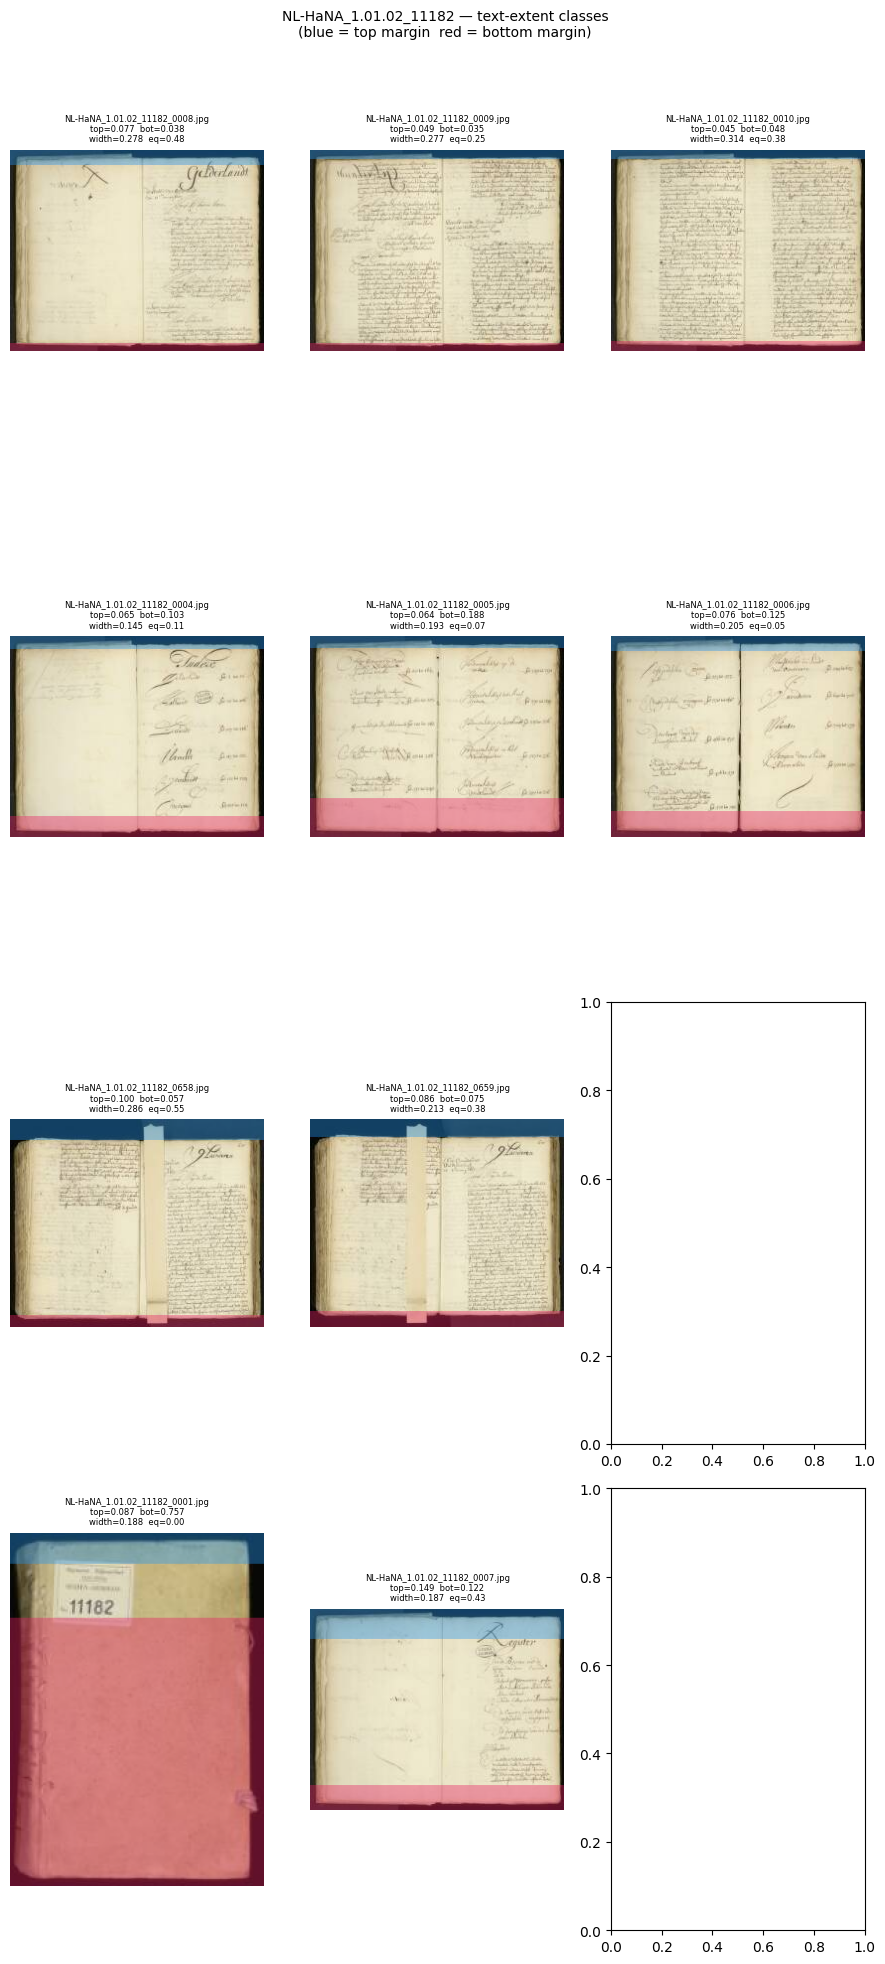

In [10]:
show_class_examples('NL-HaNA_1.01.02_11182', n_per_class=3)

## Summary

### Results table

| Inventory | Type | Full-text % | mean_width | equal_frac |
|-----------|------|-------------|------------|------------|
| NL-HaNA_1.01.02_11182 | running text (letters) | **98%** | 0.280 | 0.392 |
| NL-HaNA_1.01.02_11281 | running text (letters) | **97%** | 0.275 | 0.401 |
| NL-AsnDA_0114.11_1    | running text (deeds)   | **90%** | 0.236 | 0.306 |
| NL-HaNA_2.10.50_85    | table register         | 69%     | 0.150 | 0.139 |
| NL-HaNA_2.10.50_1     | table register         | 67%     | 0.164 | 0.143 |
| NL-HaNA_2.10.50_619   | table register         | 21%     | 0.092 | 0.107 |

### Key findings

1. **Full-text fraction separates running-text books from sparse inventories**, but two of the
   three table registers have a 67-69% full-text fraction — overlapping with the notary deeds
   (90%).  The full-text fraction alone is therefore not sufficient to distinguish *all* table
   registers from running-text books.

2. **`mean_width` is the strongest single discriminator.**  Table-register pages have narrow
   lines (0.09–0.16 relative width) because each line is a single table-cell entry, typically
   only a few characters long.  Running-text lines span the full column (0.24–0.28).  There is
   no overlap between the two types across any of the six inventories.

3. **`equal_frac` (Allen-`equal` fraction) provides complementary evidence.**  Running-text
   pages have 0.30–0.40 consecutive-pair fraction; table-register pages have 0.10–0.14.  Again
   no overlap.  The mechanism: running-text lines that fill the column share both their left and
   right boundaries from line to line; table cell entries in the same column share the left
   boundary (column position) but have variable right extents (depending on cell content),
   suppressing the equal fraction.

4. **`early_end` and `short` pages are candidate document-boundary markers** in inventories with
   a substantial full-text baseline.  In the letter books (11182, 11281) almost all non-full-text
   pages are `early_end` (22 and 18 respectively out of ~750-1100 pages), likely corresponding
   to the last page of each letter, where text ends before the page is full.  Identifying and
   sequencing these early-end pages is the focus of the companion page-sequence notebook.